## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import geopandas as gpd


# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [3]:
from gridsample.utils import save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Goverment Buildings"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [59]:
df = pd.read_csv(RAW_DATA_DIR / "gov_buildings" / "building_info_new.csv")

In [60]:
df.columns

Index(['S.No.', 'District', 'DISCOM', 'Name of Institutions/ Consumer',
       'Govt. Dept. Name', 'IVRS/ Consumer Code', 'Latitude ', 'Longitude',
       'Average Monthly Electricity Consumption (kWh)',
       'Annual Consumption (kWh)', 'Off-Peak Annual Consumption (kWh)',
       'Shadow Free useful Ground Area (sq.ft.)',
       'Shadow Free useful Roof Area (sq.ft.)',
       'Shadow Free Space Available (Sq.Ft.)',
       'Contract Demand/ Sanctioned Load (kVA)',
       'Available Capacity of DTR (kVA)',
       'Proposed Capacity as per District (kW)',
       'Proposed Capacity as per Calculation (kW)', 'Unnamed: 18',
       'Consumer's willingness to invest money for rootop system (Yes/No)',
       'Roof Quality Good for Solar Installation (Yes/No)',
       'Contact Information of Consumer',
       'Ownership a of Premises (Govt./ Private)',
       'Solar Rooftop Capacity (in kW) as per Contract Demand (C-1)',
       'Solar Rooftop Capacity (in kW) as per shadow free useful area of 

In [61]:
df.rename(
    columns={
        "Latitude ": "lat",
        "Longitude": "lon",
    },
    inplace=True,
)

# drop any rows that have nulls in lat or lon
df = df.dropna(subset=["lat", "lon"])

In [62]:
# convert to gdf
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
)

<Axes: >

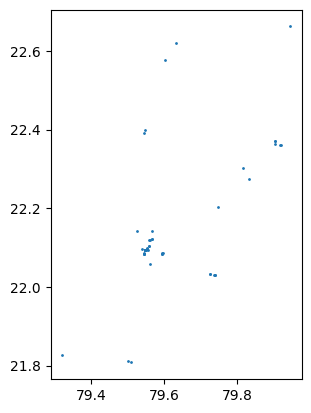

In [63]:
gdf.plot(markersize=1)

In [64]:
save_shapefiles(gdf, OUTPUT_DATA_DIR, "gov_buildings_new", formats=["parquet", "kml"])

## Clustering

<Axes: >

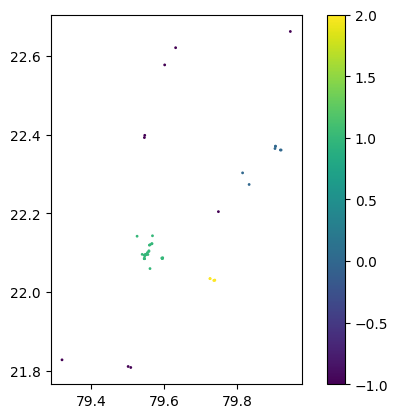

In [65]:
from sklearn.cluster import HDBSCAN

dbscan = HDBSCAN(n_jobs=-1)
gdf["cluster"] = dbscan.fit_predict(gdf[["lon", "lat"]])
gdf.plot(column="cluster", markersize=1, legend=True)

<Axes: >

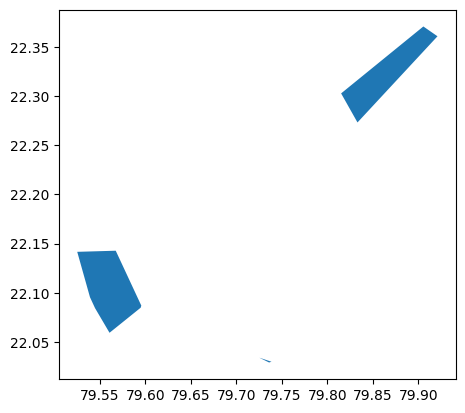

In [66]:
gdf[gdf["cluster"] >= 0].dissolve("cluster").convex_hull.plot()

## Travelling Salesman

In [101]:
gdf_projected = gdf.to_crs("EPSG:24378")

In [103]:
gdf_projected.lat = gdf_projected.geometry.y
gdf_projected.lon = gdf_projected.geometry.x

In [104]:
from scipy.spatial import distance_matrix

# Calculate the distance matrix
dist_matrix = distance_matrix(gdf_projected[["lon", "lat"]], gdf_projected[["lon", "lat"]])

In [111]:
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

In [129]:
# make list of latlon tuples
lonlat = [(lon, lat) for lon, lat in zip(gdf_projected.lon, gdf_projected.lat)]

In [ ]:
# flight number, km for each flight, time of each flight, number of buildings covered (with latlon), start point, end point, distance to cover by road to next start point

# fixed cost of time per building

In [132]:
from scipy.spatial import distance_matrix
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

# Coordinates example
coordinates = lonlat

# Distance matrix
dist_matrix = distance_matrix(coordinates, coordinates)

def create_data_model():
    return {'distance_matrix': dist_matrix, 'num_locations': len(coordinates)}

data = create_data_model()
manager = pywrapcp.RoutingIndexManager(data['num_locations'], 1, 0)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return int(data['distance_matrix'][from_node][to_node])

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
search_parameters.time_limit.seconds = 30

solution = routing.SolveWithParameters(search_parameters)

In [136]:
# Print the solution (ordered route)
if solution:
    index = routing.Start(0)
    route = []
    while not routing.IsEnd(index):
        route.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    route.append(manager.IndexToNode(index))
    print("Optimal Path:", route)

Optimal Path: [0, 14, 4, 6, 26, 27, 43, 36, 41, 35, 34, 33, 32, 31, 30, 23, 17, 37, 46, 45, 24, 38, 1, 9, 8, 25, 16, 7, 44, 3, 15, 39, 5, 2, 10, 50, 11, 19, 21, 51, 22, 12, 48, 28, 29, 20, 40, 42, 49, 18, 47, 13, 0]


In [137]:
# make a multi-line string
from shapely.geometry import LineString
from shapely.ops import linemerge

lines = []
for i in range(len(route)-1):
    lines.append(LineString([gdf.iloc[route[i]].geometry, gdf.iloc[route[i+1]].geometry]))

merged = linemerge(lines)

In [140]:
merged.length

2.6450494020515225

In [ ]:
# can travel for 1/4 sq km in 1hr
# each sq km is 18,000rs

# how long will the flight take?
# how much will it cost?
# where to bring down and put back up?


# how far can the drone get from the operator?
# how long can it be in flight?


In [ ]:
# do the paths need to be circular?

# how to convert the path into "area" to use for the costing?

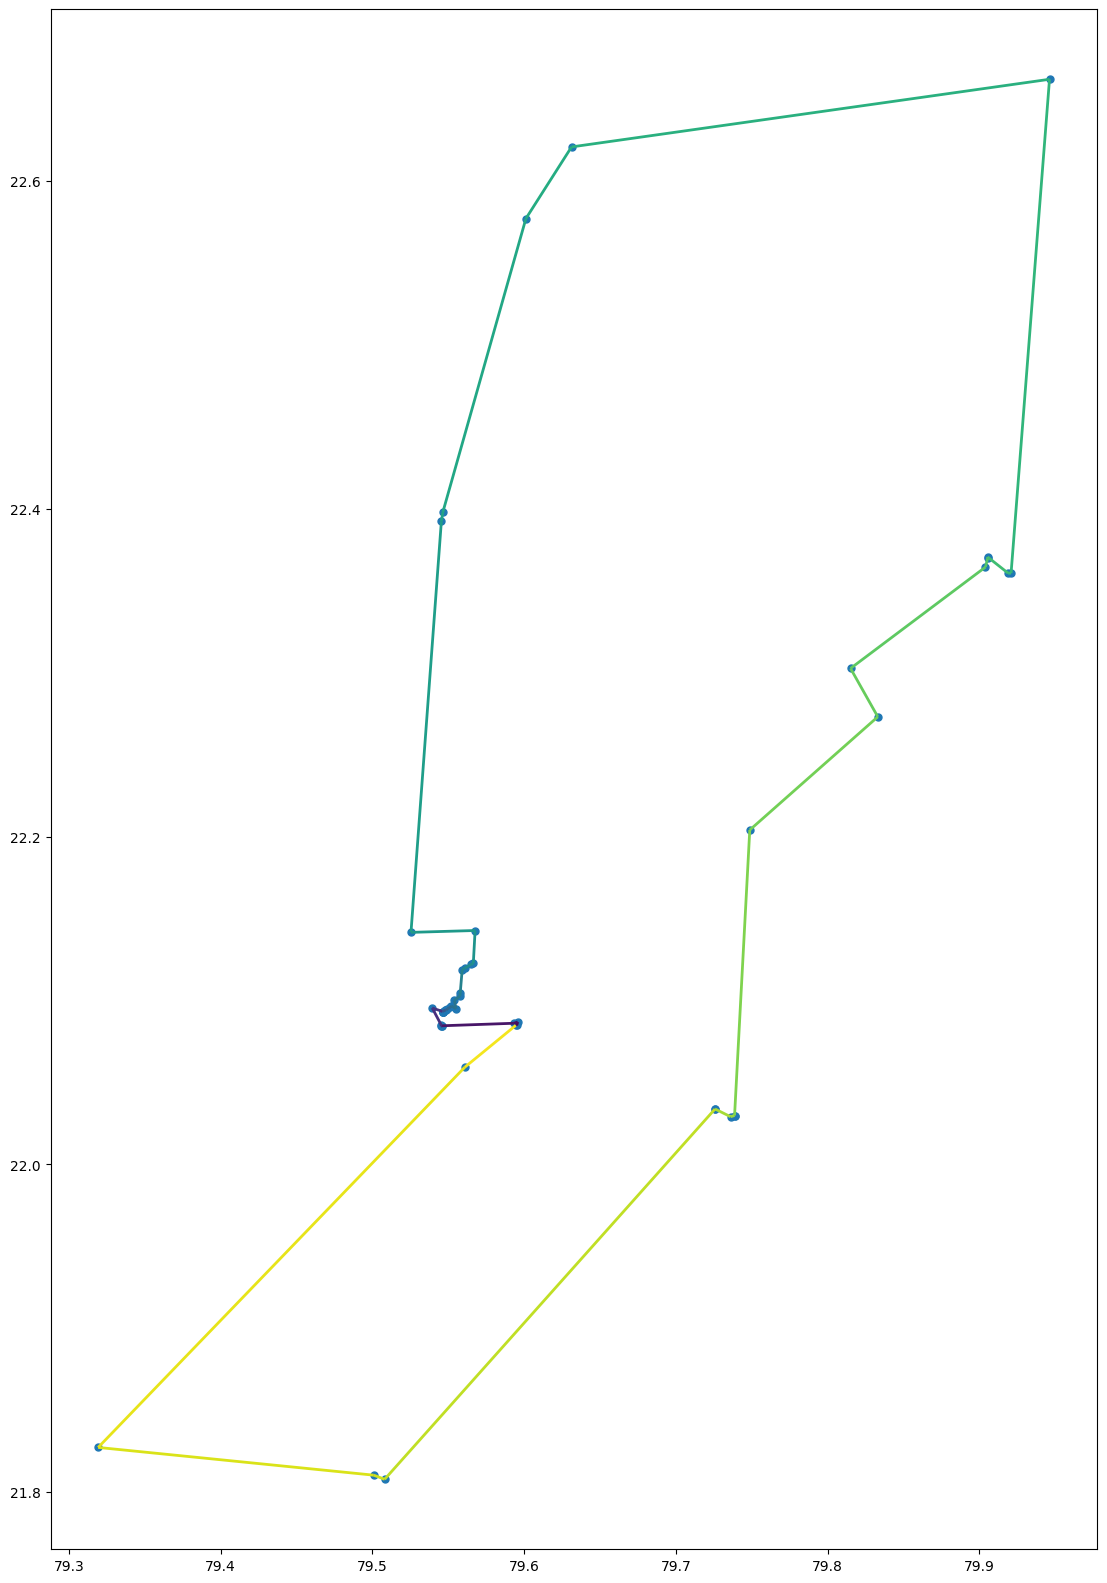

In [139]:
from matplotlib.collections import LineCollection
import numpy as np

# plot the points and the path
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20,20))
gdf.plot(ax=ax, markersize=25)
# Create a color gradient
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(0, len(lines))

# Create a list of segments with colors
segments = []
colors = []
for i, line in enumerate(lines):
    segments.append(np.array(line.coords))
    colors.append(cmap(norm(i)))

# Create a LineCollection from the segments
lc = LineCollection(segments, colors=colors, linewidth=2)

# Add the LineCollection to the plot
ax.add_collection(lc)
plt.show()